<a href="https://colab.research.google.com/github/eteitelbaum/code-satp/blob/main/model-data-size-experiments/action_type/exp_actiontype.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers datasets torch scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.4/487.4 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# def compute_metrics(eval_pred):
#     logits, labels = eval_pred
#     predictions = (torch.sigmoid(torch.tensor(logits)) > 0.5).numpy()  # Apply threshold
#     labels = labels.astype(int)

#     hamming = hamming_loss(labels, predictions)
#     subset_acc = accuracy_score(labels, predictions)
#     report = classification_report(labels, predictions, output_dict=True, zero_division=0)

#     return {
#         "hamming_loss": hamming,
#         "subset_accuracy": subset_acc,
#         "precision_micro": report["micro avg"]["precision"],
#         "recall_micro": report["micro avg"]["recall"],
#         "f1_micro": report["micro avg"]["f1-score"],
#     }

In [ ]:
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, hamming_loss, accuracy_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# =======================
# Generalized Dataset Class
# =======================
class MultiLabelDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.float),
        }

# =======================
# Function to Compute Metrics
# =======================


from sklearn.metrics import classification_report, hamming_loss, accuracy_score

def compute_metrics(eval_pred, target_names):
    """
    Compute evaluation metrics for multi-label classification.
    Includes Hamming Loss, Subset Accuracy, and Classification Report for all labels.
    """
    logits, labels = eval_pred
    predictions = (torch.sigmoid(torch.tensor(logits)) > 0.5).numpy()  # Apply threshold
    labels = labels.astype(int)

    # Verify Labels
    print("Shape of labels:", labels.shape)  # Ensures correct dimensions
    print("First few rows of labels:\n", labels[:5])  # Shows the first few rows to check for issues
    print("Final target names:", target_names)

    # Hamming Loss
    hamming = hamming_loss(labels, predictions)

    # Subset Accuracy
    subset_acc = accuracy_score(labels, predictions)

    # Classification Report
    report = classification_report(
        labels, predictions,
        target_names=target_names,
        zero_division=0, output_dict=True
    )

    # Print complete report for reference
    print("\nFull Classification Report:")
    print(classification_report(labels, predictions, target_names=target_names, zero_division=0))


    # Summary Metrics for Trainer
    metrics = {
        "hamming_loss": hamming,
        "subset_accuracy": subset_acc,
    }
    metrics.update(report)
    return metrics


# =============================
# Reusable Training Function
# =============================

def train_transformer_model(model_name, data, max_len=512, test_size=0.1, val_size=0.1, batch_size=40, epochs=3):
    """
    Generalized function to train a transformer model for multi-label classification.
    Args:
        model_name: Name of the pre-trained model (e.g., "bert-base-uncased", "distilbert-base-uncased").
        data: Pandas DataFrame with columns "incident_summary" and multi-label columns.
        max_len: Maximum sequence length.
        batch_size: Batch size for training and evaluation.
        epochs: Number of training epochs.
    """

    # Define target names
    target_names = data.drop(columns=["incident_summary"]).columns.tolist()

    # Load tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=data.shape[1] - 1,  # Number of labels (all columns except "incident_summary")
        problem_type="multi_label_classification",
    )
    model.to("cuda" if torch.cuda.is_available() else "cpu")

    # Split data into train, val, and test
    X = data["incident_summary"]
    y = data.drop('incident_summary', axis=1).values

    # Verify columns
    print("Shape of y:", y.shape)  # Checks the dimensions of y
    print("First few rows of y:\n", y[:5])  # Prints the first few rows of y to inspect its contents

    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=test_size, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=val_size, random_state=42)

    # Create datasets
    train_dataset = MultiLabelDataset(X_train.tolist(), y_train, tokenizer, max_len)
    val_dataset = MultiLabelDataset(X_val.tolist(), y_val, tokenizer, max_len)
    test_dataset = MultiLabelDataset(X_test.tolist(), y_test, tokenizer, max_len)

    # Define training arguments
    training_args = TrainingArguments(
        output_dir="./results",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01,
        logging_dir="./logs",
        logging_steps=10,
        load_best_model_at_end=True,
        metric_for_best_model='eval_hamming_loss',
        greater_is_better=True,
        save_total_limit=2,
        report_to="none",
    )

    # Initialize Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        compute_metrics=lambda eval_pred: compute_metrics(eval_pred, target_names)  # ✅ Passing target_names
    )

    # Train and Evaluate
    trainer.train()

    # Final Evaluation on Test Set
    test_results = trainer.evaluate(test_dataset)
    print("Test Set Results:", test_results)

    return trainer, test_results


In [ ]:
fraction_labels = {
    1/32: "3%",   # 1/32 = 3.125%
    1/16: "6%",   # 1/16 = 6.25%
    1/8:  "12%",  # 1/8  = 12.5%
    1/4:  "25%",
    1/2:  "50%",
    1.0:  "100%"
}

model_name_labels = {
    "bert-base-cased": "BERT",
    "snowood1/ConfliBERT-scr-cased": "ConfliBERT",
    "FacebookAI/roberta-base": "RoBERTa",
    "distilbert-base-cased": "DistilBERT",
    "xlnet-base-cased": "XLNet",
    "google/electra-base-discriminator": "ELECTRA"
}

fractions = [1/32, 1/16, 1/8, 1/4, 1/2, 1.0]

models_list = [
    "bert-base-cased",
    "snowood1/ConfliBERT-scr-cased",
    "FacebookAI/roberta-base",
    "distilbert-base-cased",
    "xlnet-base-cased",
    "google/electra-base-discriminator"
]

In [ ]:
def run_all_experiments_and_save(df_full, output_csv="experiment_results.csv"):
    """
    1. Iterates over the defined fractions & model list
    2. Samples df_full according to fraction
    3. Trains & evaluates using train_multiclass_model_3way_split
    4. Saves the collected results in a DataFrame
    5. Exports to CSV

    Args:
        df_full (pd.DataFrame): Full dataset with columns [label_col, text_col].
        output_csv (str): File path to save the experiment results.
    Returns:
        results_df (pd.DataFrame): Contains experiment results for analysis.
    """
    results_list = []

    for frac in fractions:
        # Sample a fraction of the data
        subset_size = int(len(df_full) * frac)
        df_subset = df_full.sample(n=subset_size, random_state=42)

        # Friendly fraction label if you want
        frac_label = fraction_labels.get(frac, f"{frac*100:.1f}%")
        print(f"\n=== DATA FRACTION: {frac} ({subset_size} rows) ===")

        for model_name in models_list:
            # Model label
            model_label = model_name_labels.get(model_name, model_name)
            print(f"Training model: {model_label}")

            # Train & evaluate
            # write the model funtion here
            trainer, test_results = train_transformer_model(model_name, df_subset, max_len=512, test_size=0.1, val_size=0.1, batch_size=16, epochs=2)


            # Build a result dict
            run_result = {
                "fraction_raw": frac,
                "fraction_label": frac_label,
                "subset_size": subset_size,
                "model_raw": model_name,
                "model_label": model_label
            }

            # Flatten the nested dictionary
            for key, value in test_results.items():
                if isinstance(value, dict):
                    for subkey, subvalue in value.items():
                        # Create new key names like "armed_assault_precision"
                        run_result[f"{key}_{subkey}"] = subvalue
                else:
                    run_result[key] = value

            # Append to results_list
            results_list.append(run_result)

    # Convert to DataFrame
    results_df = pd.DataFrame(results_list)
    # Save to CSV
    results_df.to_csv(output_csv, index=False)
    print(f"\nResults saved to {output_csv}")

    # also save to JSON
    # results_df.to_json("experiment_results.json", orient="records")

    return results_df




#**Read from GitHub**

In [ ]:
import pandas as pd

# Corrected URL to access the raw CSV data
url = 'https://raw.githubusercontent.com/eteitelbaum/code-satp/main/model-data-size-experiments/action_type/action_type.csv'

try:
    data = pd.read_csv(url)
    print(data.head())
except Exception as e:
    print(f"Error loading CSV from URL: {e}")

# **Read From Drive**

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/colab/satp-data/action_type.csv')

data.head()

Mounted at /content/drive


,armed_assault,arrest,bombing,infrastructure,surrender,seizure,abduction,incident_summary
0,0,1,0,0,0,0,0,An alleged arms supplier to the Communist Part...
1,0,0,0,0,1,0,0,A Kamareddy dalam (squad) member belonging to ...
2,0,1,0,0,0,0,0,Senior CPI-Maoist 'Polit Bureau' and 'central ...
3,1,0,0,0,0,0,0,A TDP leader and former Sarpanch of Jerrela Gr...
4,0,0,1,1,0,0,0,The CPI-Maoist cadres blasted coffee pulping u...


# **Loop Models**

In [ ]:

# Example usage:
final_results_df = run_all_experiments_and_save(data, output_csv="experiment_results.csv")

# Now you can inspect final_results_df in Python:
print(final_results_df.head())

# If you want to do more analysis, you can pivot, group, or plot the data.



=== DATA FRACTION: 0.03125 (310 rows) ===
Training model: BERT


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

...

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at google/electra-base-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Shape of y: (9921, 7)
First few rows of y:
 [[0 0 0 1 0 0 0]
 [1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]]


Epoch,Training Loss,Validation Loss,Hamming Loss,Subset Accuracy,Armed Assault,Arrest,Bombing,Infrastructure,Surrender,Seizure,Abduction,Micro avg,Macro avg,Weighted avg,Samples avg,Runtime,Samples Per Second,Steps Per Second
1,0.093900,0.095411,0.027036,0.854423,"{'precision': 0.9623188405797102, 'recall': 0.9273743016759777, 'f1-score': 0.9445234708392604, 'support': 358.0}","{'precision': 0.9846743295019157, 'recall': 0.9809160305343512, 'f1-score': 0.982791586998088, 'support': 262.0}","{'precision': 0.883495145631068, 'recall': 0.875, 'f1-score': 0.8792270531400966, 'support': 104.0}","{'precision': 0.9135802469135802, 'recall': 0.7789473684210526, 'f1-score': 0.8409090909090909, 'support': 95.0}","{'precision': 1.0, 'recall': 0.9848484848484849, 'f1-score': 0.9923664122137404, 'support': 66.0}","{'precision': 0.8814432989690721, 'recall': 0.9395604395604396, 'f1-score': 0.9095744680851063, 'support': 182.0}","{'precision': 1.0, 'recall': 0.4107142857142857, 'f1-score': 0.5822784810126582, 'support': 56.0}","{'precision': 0.9449626865671642, 'recall': 0.9020480854853072, 'f1-score': 0.9230068337129841, 'support': 1123.0}","{'precision': 0.9465016945136211, 'recall': 0.8424801301077988, 'f1-score': 0.8759529375997201, 'support': 1123.0}","{'precision': 0.9470980572322623, 'recall': 0.9020480854853072, 'f1-score': 0.9177231583714986, 'support': 1123.0}","{'precision': 0.9518477043673013, 'recall': 0.9279581933557297, 'f1-score': 0.9310936916759985, 'support': 1123.0}",7.278300,122.694000,7.694000
2,0.087700,0.075295,0.023196,0.877940,"{'precision': 0.9653179190751445, 'recall': 0.9329608938547486, 'f1-score': 0.9488636363636364, 'support': 358.0}","{'precision': 0.9848484848484849, 'recall': 0.9923664122137404, 'f1-score': 0.9885931558935361, 'support': 262.0}","{'precision': 0.8584070796460177, 'recall': 0.9326923076923077, 'f1-score': 0.8940092165898618, 'support': 104.0}","{'precision': 0.8823529411764706, 'recall': 0.7894736842105263, 'f1-score': 0.8333333333333334, 'support': 95.0}","{'precision': 1.0, 'recall': 0.9848484848484849, 'f1-score': 0.9923664122137404, 'support': 66.0}","{'precision': 0.9120879120879121, 'recall': 0.9120879120879121, 'f1-score': 0.9120879120879121, 'support': 182.0}","{'precision': 0.9333333333333333, 'recall': 0.75, 'f1-score': 0.8316831683168316, 'support': 56.0}","{'precision': 0.9445454545454546, 'recall': 0.92520035618878, 'f1-score': 0.9347728295096717, 'support': 1123.0}","{'precision': 0.9337639528810521, 'recall': 0.8992042421296743, 'f1-score': 0.9144195478284074, 'support': 1123.0}","{'precision': 0.9447717278903137, 'recall': 0.92520035618878, 'f1-score': 0.9340326397917631, 'support': 1123.0}","{'precision': 0.9522209779768569, 'recall': 0.9430757745427398, 'f1-score': 0.9407614781634939, 'support': 1123.0}",7.311100,122.142000,7.660000


Shape of labels: (893, 7)
First few rows of labels:
 [[0 0 0 0 0 1 0]
 [0 1 0 0 0 0 0]
 [0 1 0 0 0 0 0]
 [0 1 0 0 0 0 0]
 [0 0 0 0 1 0 0]]
Final target names: ['armed_assault', 'arrest', 'bombing', 'infrastructure', 'surrender', 'seizure', 'abduction']

Full Classification Report:
                precision    recall  f1-score   support

 armed_assault       0.96      0.93      0.94       358
        arrest       0.98      0.98      0.98       262
       bombing       0.88      0.88      0.88       104
infrastructure       0.91      0.78      0.84        95
     surrender       1.00      0.98      0.99        66
       seizure       0.88      0.94      0.91       182
     abduction       1.00      0.41      0.58        56

     micro avg       0.94      0.90      0.92      1123
     macro avg       0.95      0.84      0.88      1123
  weighted avg       0.95      0.90      0.92      1123
   samples avg       0.95      0.93      0.93      1123

Shape of labels: (893, 7)
First few rows of

Shape of labels: (100, 7)
First few rows of labels:
 [[0 0 0 0 1 0 0]
 [0 0 0 0 1 0 0]
 [0 0 1 0 0 0 0]
 [1 0 0 0 0 0 0]
 [0 0 0 1 0 0 0]]
Final target names: ['armed_assault', 'arrest', 'bombing', 'infrastructure', 'surrender', 'seizure', 'abduction']

Full Classification Report:
                precision    recall  f1-score   support

 armed_assault       0.89      0.97      0.93        33
        arrest       0.96      0.92      0.94        24
       bombing       0.71      0.71      0.71        14
infrastructure       0.92      0.92      0.92        12
     surrender       1.00      1.00      1.00         8
       seizure       0.86      0.86      0.86        21
     abduction       1.00      0.67      0.80         3

     micro avg       0.89      0.90      0.89       115
     macro avg       0.90      0.86      0.88       115
  weighted avg       0.89      0.90      0.89       115
   samples avg       0.90      0.91      0.89       115

Test Set Results: {'eval_loss': 0.101340368

In [ ]:
import os


def save_to_drive(df, filename, folder_name="actiontype"):
    base_path = "/content/drive/MyDrive/colab/satp-results/"
    drive_path = os.path.join(base_path, folder_name)

    # Create the folder if it doesn't exist
    if not os.path.exists(drive_path):
        os.makedirs(drive_path)

    filepath = os.path.join(drive_path, filename)
    df.to_csv(filepath, index=False)
    print(f"✅ DataFrame saved to: {filepath}")

save_to_drive(final_results_df, "actiontype_results.csv")


NameError: name 'final_results_df' is not defined

## Data Analysis

In [2]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#read csv from drive
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/colab/satp-results/actiontype/actiontype_results.csv')

### What to Visualize?

1. Eval F1 macro average

### Eval F1 Macro

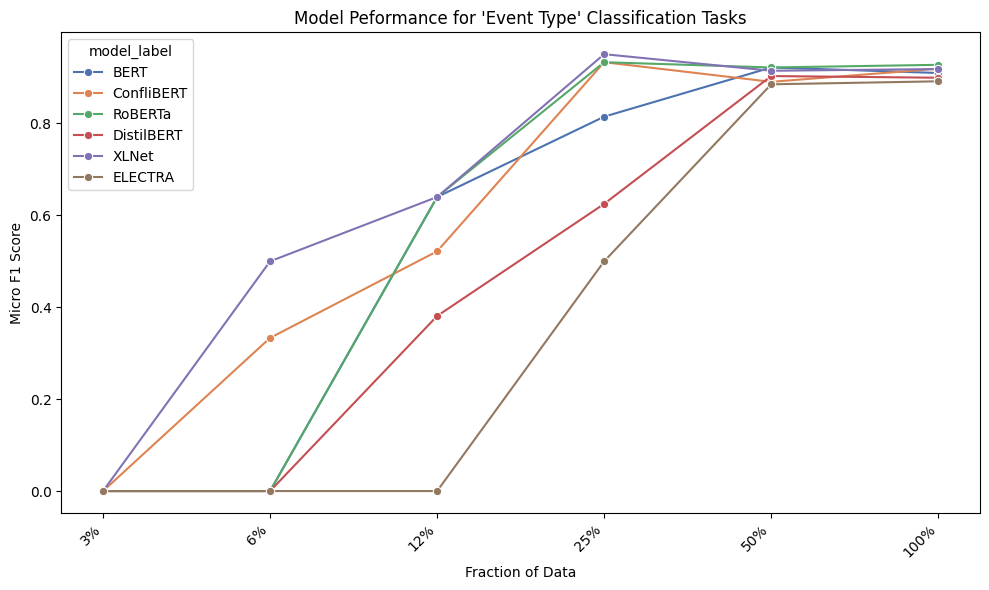

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the plot
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="fraction_label",
    y="eval_micro avg_f1-score",
    hue="model_label",
    marker="o",
    palette="colorblind"
    )

# Customize the plot
plt.xlabel("Fraction of Data")
plt.ylabel("Micro F1 Score")
plt.title("Model Peformance for 'Event Type' Classification Tasks")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()


### Heatmap of individual labels

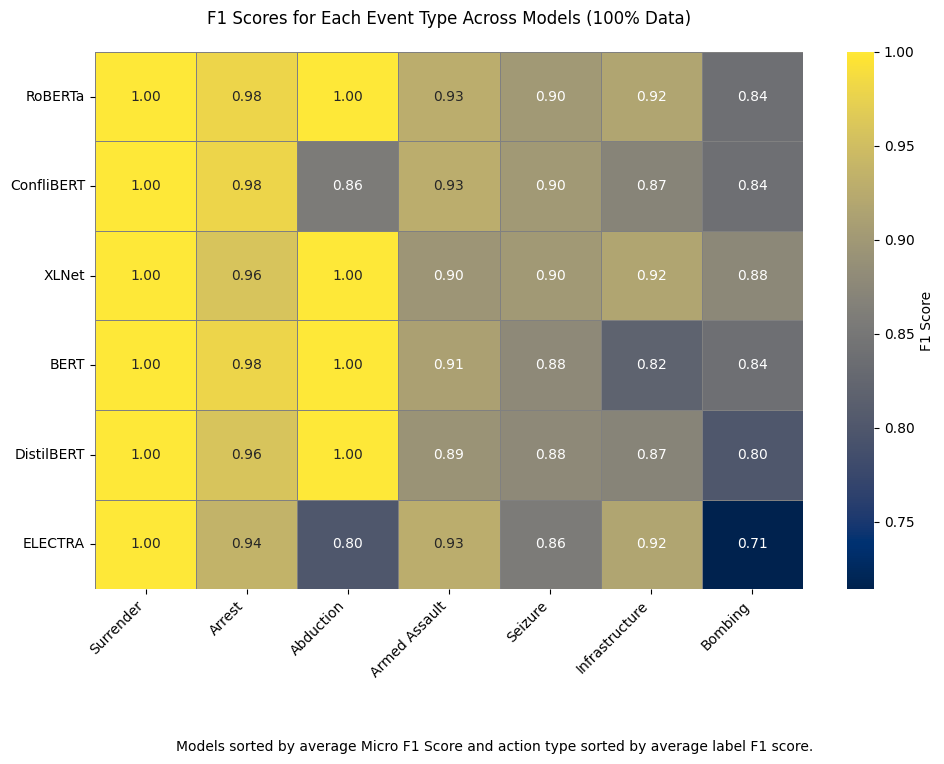

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the dataset for models trained on 100% of the data
df_100 = df[df["fraction_label"] == "100%"]

# Extract F1-score columns related to specific labels (excluding averages)
label_f1_columns = [col for col in df_100.columns if col.startswith("eval_") and "_f1-score" in col and "avg" not in col]

# Select only the relevant columns along with the model label
df_f1_100 = df_100[["model_label"] + label_f1_columns]

# Rename "ConfliBERT-scr-cased" to "ConfliBERT" for clarity
#df_f1_100["model_label"] = df_f1_100["model_label"].replace({"ConfliBERT-scr-cased": "ConfliBERT"})

# Convert data to long format for heatmap visualization
df_f1_melted_100 = df_f1_100.melt(id_vars=["model_label"], var_name="Label", value_name="F1 Score")

# Clean label names (remove "eval_" prefix and "_f1-score" suffix for readability)
df_f1_melted_100["Label"] = df_f1_melted_100["Label"].str.replace("eval_", "").str.replace("_f1-score", "").str.replace("_", " ").str.title()

# Pivot the table so that models are on the y-axis and event types on the x-axis
df_f1_pivot_100 = df_f1_melted_100.pivot(index="model_label", columns="Label", values="F1 Score")

# Remove "Incident Summary" if it exists
df_f1_pivot_100 = df_f1_pivot_100.drop(columns="Incident Summary", errors="ignore")

# Sort event types (columns) by their average F1 score across models (descending order)
event_order = df_f1_pivot_100.mean().sort_values(ascending=False).index
df_f1_pivot_100 = df_f1_pivot_100[event_order]

# Sort models (rows) by their Micro F1 score (descending order) while ensuring all models are included
df_model_avg_f1 = df_100.set_index("model_label")["eval_micro avg_f1-score"].sort_values(ascending=False)
model_order = df_model_avg_f1.index
df_f1_pivot_100 = df_f1_pivot_100.loc[model_order]

# Plot the heatmap
plt.figure(figsize=(10, 7))
ax = sns.heatmap(df_f1_pivot_100, annot=True, fmt=".2f", cmap="cividis", linewidths=0.5, linecolor="gray", cbar_kws={'label': 'F1 Score'})

# Customize the plot
ax.set_title("F1 Scores for Each Event Type Across Models (100% Data)", pad=20)

# Add a custom note
plt.figtext(0.5, -0.08,
            "Models sorted by average Micro F1 Score and action type sorted by average label F1 score.",
            ha="center", fontsize=10)

# Remove X and Y axis labels
ax.set_xlabel("")
ax.set_ylabel("")

# Move event type labels (x-axis) to the bottom
ax.xaxis.tick_bottom()
ax.xaxis.set_label_position('bottom')

# Adjust ticks
plt.xticks(rotation=45, ha="right")  # Rotate labels for readability
plt.yticks(rotation=0)

# Show the heatmap
plt.tight_layout()
plt.show()
